In [ ]:
# Install extra packages (only first time)
!pip install pandas matplotlib openpyxl

In [ ]:
# Import Python libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files


In [ ]:
# Set up API
api_key = "ba23f52a2ed944734820182e57ece01b"
city = "Goa"
url = f"http://api.openweathermap.org/data/2.5/forecast?q={city}&appid={api_key}&units=metric"

# Fetch forecast data
response = requests.get(url)
data = response.json()

# Extract data from JSON
forecast_data = []

for entry in data["list"]:
    forecast_data.append({
        "datetime": entry["dt_txt"],
        "temperature (°C)": entry["main"]["temp"],
        "humidity (%)": entry["main"]["humidity"],
        "description": entry["weather"][0]["description"]
    })

# Convert to DataFrame
df = pd.DataFrame(forecast_data)
df["datetime"] = pd.to_datetime(df["datetime"])  # Convert string to datetime
df.head()


,datetime,temperature (°C),humidity (%),description
0,2025-08-11 06:00:00,25.21,72,light rain
1,2025-08-11 09:00:00,26.63,70,light rain
2,2025-08-11 12:00:00,27.05,71,light rain
3,2025-08-11 15:00:00,25.13,88,light rain
4,2025-08-11 18:00:00,24.07,89,light rain


In [ ]:
# Save to CSV
df.to_csv("weather_forecast.csv", index=False)

# Download the file to your device
files.download("weather_forecast.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Step 1: Install required libraries
!pip install pandas matplotlib openpyxl

# Step 2: Import libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files


In [ ]:
# Step 3: API setup and fetch data
api_key = "ba23f52a2ed944734820182e57ece01b"
city = "Goa"
url = f"http://api.openweathermap.org/data/2.5/forecast?q={city}&appid={api_key}&units=metric"

response = requests.get(url)
data = response.json()


In [ ]:
# Step 4: Extract as much data as possible from the forecast
forecast_data = []

for entry in data["list"]:
    forecast_data.append({
        "datetime": entry["dt_txt"],
        "temperature (°C)": entry["main"]["temp"],
        "feels_like (°C)": entry["main"]["feels_like"],
        "temp_min (°C)": entry["main"]["temp_min"],
        "temp_max (°C)": entry["main"]["temp_max"],
        "pressure (hPa)": entry["main"]["pressure"],
        "humidity (%)": entry["main"]["humidity"],
        "sea_level (hPa)": entry["main"].get("sea_level", None),
        "ground_level (hPa)": entry["main"].get("grnd_level", None),
        "weather_main": entry["weather"][0]["main"],
        "weather_description": entry["weather"][0]["description"],
        "weather_icon": entry["weather"][0]["icon"],
        "cloudiness (%)": entry["clouds"]["all"],
        "wind_speed (m/s)": entry["wind"]["speed"],
        "wind_deg (°)": entry["wind"]["deg"],
        "wind_gust (m/s)": entry["wind"].get("gust", None),
        "visibility (m)": entry.get("visibility", None),
        "pop (Probability of precipitation)": entry.get("pop", 0),
    })

df = pd.DataFrame(forecast_data)
df["datetime"] = pd.to_datetime(df["datetime"])
df.head()


,datetime,temperature (°C),feels_like (°C),temp_min (°C),temp_max (°C),pressure (hPa),humidity (%),sea_level (hPa),ground_level (hPa),weather_main,weather_description,weather_icon,cloudiness (%),wind_speed (m/s),wind_deg (°),wind_gust (m/s),visibility (m),pop (Probability of precipitation)
0,2025-08-11 06:00:00,25.21,25.74,25.21,29.27,1011,75,1011,999,Rain,light rain,10d,95,3.25,256,4.07,10000,0.37
1,2025-08-11 09:00:00,26.63,26.63,26.63,29.46,1010,73,1010,997,Rain,light rain,10d,97,3.58,269,4.48,10000,1.00
2,2025-08-11 12:00:00,27.05,29.11,27.05,27.97,1010,72,1010,996,Rain,light rain,10d,97,3.19,272,4.55,10000,0.99
3,2025-08-11 15:00:00,25.13,26.00,25.13,25.13,1011,88,1011,998,Rain,light rain,10n,82,1.09,261,1.66,10000,1.00
4,2025-08-11 18:00:00,24.07,24.86,24.07,24.07,1011,89,1011,998,Rain,light rain,10n,90,0.37,237,0.36,10000,1.00


In [ ]:
# Step 5: Save and download the CSV
df.to_csv("full_weather_forecast.csv", index=False)
files.download("full_weather_forecast.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

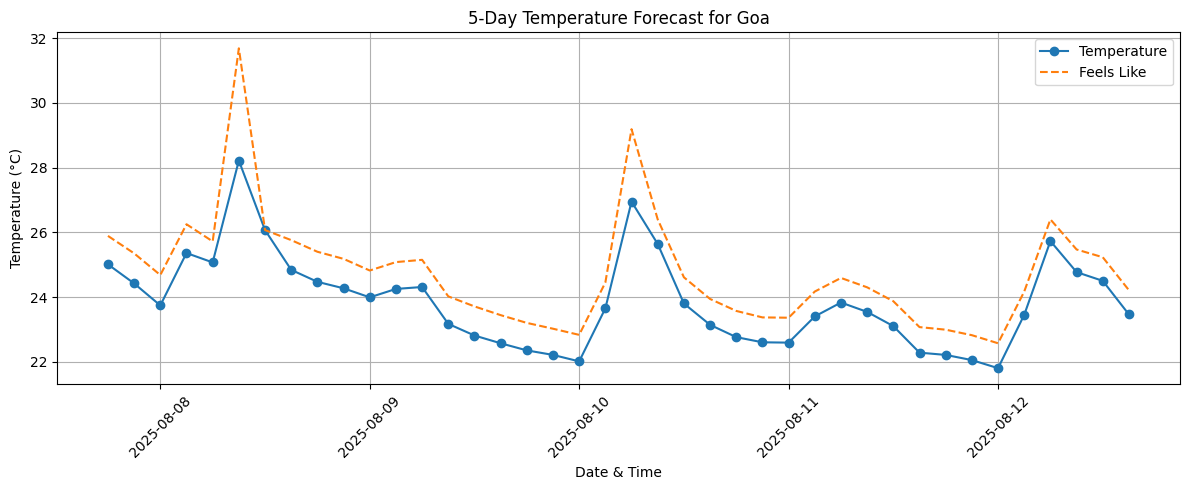

In [ ]:
# Step 6: Simple Temperature Visualization
plt.figure(figsize=(12, 5))
plt.plot(df["datetime"], df["temperature (°C)"], marker='o', label="Temperature")
plt.plot(df["datetime"], df["feels_like (°C)"], linestyle='--', label="Feels Like")
plt.xticks(rotation=45)
plt.title(f"5-Day Temperature Forecast for {city}")
plt.xlabel("Date & Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load data
df = pd.read_csv("your_weather_data.csv", encoding='latin1', errors='replace')


# Create target column
df['rain'] = df['weather_main'].apply(lambda x: 1 if 'Rain' in x or 'Drizzle' in x else 0)

# Select features
features = ['pressure', 'humidity', 'pop', 'cloudiness']
X = df[features]
y = df['rain']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))


TypeError: read_csv() got an unexpected keyword argument 'errors'